# Signal processing of the ambient noise recordings of integrated fibre optic data


In [2]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import hilbert
from scipy.signal import iirfilter, sosfiltfilt
import scipy

We start with defining functions to detrend and taper the data

In [3]:

def detrend(data_in):
    data = data_in.copy()
    ndat = len(data)
    x1, x2 = data[0], data[-1]
    data -= x1 + np.arange(ndat) * (x2 - x1) / float(ndat - 1)
    return data


def taper(data_in, taper_ratio=0.01):
    """
    Taper both edges of timeseries

    :param data: Data to taper. 2D numpy array [ npts, nchan ]
                  OR a 1D numpy array [ npts, ]
    :param taper_ratio: fraction of data to taper, between 0 and 0.5
                  i.e., 0.01 means 1%
    :return: tapered data
    """
    data = data_in.copy()
    if(data.dtype!="float64"):
        data = data.astype('float64')

    
    npts = np.shape(data)[0]
    lwind = int(npts*taper_ratio)
    taper = np.linspace(0,1,lwind)#[None].T
    
    if(len(data.shape) == 2):
        data[:lwind,:] *= taper[None].T
        data[-lwind:,:] *= np.flipud(taper[None].T)

    elif(len(data.shape) == 1):
        data[:lwind] *= taper
        data[-lwind:] *= np.flipud(taper)
    return data





We load in the data folder, with the corresponding sampling frequency FS

In [24]:
time = []
freq = []

path = 'path/to/data'

files = glob.glob(path + '/*.txt')


FS = 500
NSAMP = 100000
MAXSHIFT = 50*FS
NFFT = (2.0**np.round(np.log2(NSAMP))).astype(int)

# create empty list to store dataframes
acorr_raw = np.zeros([len(files),2*MAXSHIFT])
acorr_inte = np.zeros([len(files),2*MAXSHIFT])


# loop through list of files and read each one into a dataframe and append to list
for ii,f in enumerate(files):
    print(ii,f)
    # read in csv
    df = pd.read_csv(f,header=None)
    if(np.shape(df)[0] != NSAMP):
        print("ERROR, File has incorrect number of samples")
        continue

    time=df.drop([1], axis=1)#drop along row = first row


    #-- Prepare Raw
    raw = df[1].copy().to_numpy()
    raw = raw - np.mean(raw)
    raw2 = scipy.signal.detrend(raw)
    raw2 = taper(raw2)


    #-- Integrate
    corrfreq = np.cumsum(raw)
    #corrfreq = scipy.signal.detrend(corrfreq)
    corrfreq = detrend(corrfreq)
    corrfreq = taper(corrfreq,taper_ratio=0.01)

    #-- FILTER
    freqmin=.1 #Hz
    freqmax=100
    fe=0.5*FS   # fe=250Hz
    low=freqmin/fe
    high=freqmax/fe
    sos=iirfilter(4,[low,high], btype='band', ftype='butter',output='sos')
    corrfreq_filt = signal.sosfiltfilt(sos, corrfreq)
    raw2_filt     = signal.sosfiltfilt(sos, raw2)





    #-- Autocorrelation, on Raw
    MAXSHIFT = 50*FS
    NFFT = (2.0**np.round(np.log2(len(raw)))).astype(int)
    spec = np.fft.rfft(raw2_filt,n=NFFT).astype(np.complex64)
    spec_conj = np.conj(spec)
    tmp_spect = spec_conj*spec
    tmp_time  = np.fft.irfft(tmp_spect,n=NFFT,axis=0)
    corr = np.hstack( [tmp_time[NFFT-MAXSHIFT:NFFT],tmp_time[0:MAXSHIFT]] )
    acorr_raw[ii,:] = corr

    #-- Autocorrelation, on Integrated
    MAXSHIFT = 50*FS
    NFFT = (2.0**np.round(np.log2(len(raw)))).astype(int)
    spec = np.fft.rfft(corrfreq_filt,n=NFFT).astype(np.complex64)
    spec_conj = np.conj(spec)
    tmp_spect = spec_conj*spec
    tmp_time  = np.fft.irfft(tmp_spect,n=NFFT,axis=0)
    corr = np.hstack( [tmp_time[NFFT-MAXSHIFT:NFFT],tmp_time[0:MAXSHIFT]] )
    acorr_inte[ii,:] = corr


np.save("all_time_series.npy",acorr_raw, acorr_inte)

We plot the resulting time series, for different frequencies

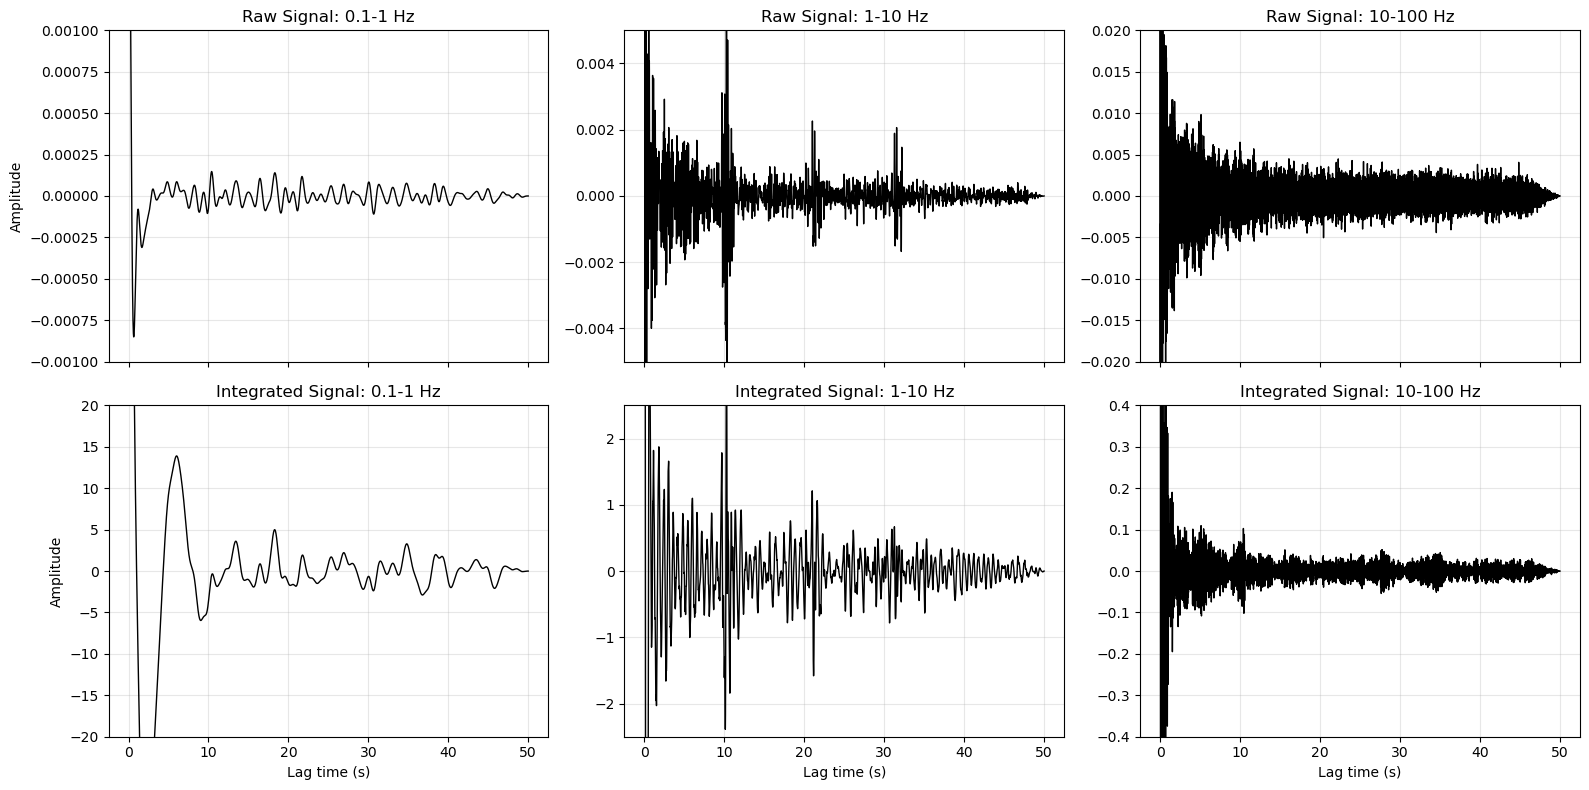

In [23]:
ylims = [
    [(-0.001, 0.001), (-0.005, 0.005), (-0.02, 0.02)],  # raw
    [(-20, 20),   (-2.5, 2.5), (-0.4, 0.4)]     # integrated
]

corrstack_raw = np.mean(acorr_raw, axis=0)
corrstack_inte = np.mean(acorr_inte, axis=0)

tt = np.linspace(-MAXSHIFT / FS, MAXSHIFT / FS, np.shape(acorr_raw)[1])

# Frequency bands to plot
bands = [(0.1, 1), (1, 10), (10, 100)]
signal_names = ["Raw Signal", "Integrated Signal"]
corrstacks = [corrstack_raw, corrstack_inte]

fe = 0.5 * FS  # Nyquist frequency

fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=False)

for col, (freqmin, freqmax) in enumerate(bands):
    low = freqmin / fe
    high = freqmax / fe

    # Safety check: band must be below Nyquist
    if high >= 1:
        raise ValueError(
            f"Upper band edge {freqmax} Hz is at/above Nyquist frequency {fe} Hz."
        )

    sos = iirfilter(
        4, [low, high],
        btype='band',
        ftype='butter',
        output='sos'
    )

    for row, corrstack in enumerate(corrstacks):
        tmp = taper(corrstack, taper_ratio=0.05)
        tmp = signal.sosfiltfilt(sos, tmp)

        axs[row, col].plot(tt[MAXSHIFT:], tmp[MAXSHIFT:], color='k', lw=1)
        axs[row, col].set_title(f"{signal_names[row]}: {freqmin}-{freqmax} Hz")
        axs[row, col].grid(True, alpha=0.3)
        axs[row, col].set_ylim(*ylims[row][col])

# Labels
for ax in axs[-1, :]:
    ax.set_xlabel("Lag time (s)")
for ax in axs[:, 0]:
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()